In [1]:
import numpy as np
import pandas as pd
from SWMM import SWMM_ENV as SWMM_ENV
from HC import HC as HC
import datetime
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import os
import yaml

import datetime

from MPC import pso
import pyswmm
from swmm_api.input_file import read_inp_file
from pyswmm import Simulation,Links,Nodes,RainGages,SystemStats
from swmm_api.input_file.sections.others import TimeseriesData
from swmm_api.input_file.sections import Control
from swmm_api.input_file.section_labels import TIMESERIES, CONTROLS
from swmm_api import read_rpt_file, SwmmReport

from scipy import stats
import math

E:\Anaconda\envs\drainage\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Rainfall

In [2]:
raindata = np.load('rainfall/real_raindata.npy').tolist()
print(len(raindata))

4


In [3]:
raindata = [
    [
        [time, str(float(rain) * 5)]
        for time, rain in event
    ]
    for event in raindata
]

In [4]:
num_rainfalls = 4

# Initialize directory structure for temporary files

In [5]:
if not os.path.exists('./SWMM_GR/_temopt'):
    os.makedirs('./SWMM_GR/_temopt')

for rainid in range(num_rainfalls):
    # rainid += 50
    temp_folder = f'./SWMM_GR/_temopt/tem_rain{rainid}'
    if not os.path.exists(temp_folder):
        os.makedirs(temp_folder)

# Define Environment: External control model vs. Internal optimization model

## Optimization helper functions

In [6]:
def step_results(sim,config,params):
    results = {'CSO':[0], 
               'flooding':[0], 
               'inflow':[0],
               'total_flooding_time':[0], 
                'total_CSO_time':[0],
                'res':[0],
                'state':[0],
                'action':[0], 
                'rewards':[0]
    }
    
    # Retrieve simulation state variables
    nodes = Nodes(sim)
    links = Links(sim)
    rgs = RainGages(sim)
    sys = SystemStats(sim)

    # obtain states and reward term by yaml (config)
    states = []
    for _temp in config["states"]:
        if _temp[1] == 'depthN':
            states.append(nodes[_temp[0]].depth)
        elif _temp[1] == 'flow':
            states.append(links[_temp[0]].flow)
        elif _temp[1] == 'inflow':
            states.append(nodes[_temp[0]].total_inflow)
        else:
            states.append(rgs[_temp[0]].rainfall)
        
    results, reward = SWMM_ENV.get_step_results(results,nodes,links,rgs,sys,config,params)
    results['state'].append(states)
    results['rewards'].append(reward)
        
    return states,reward,results

In [7]:
def calobjValue_mp(actions_set,step,rainid,ta_original):
    action_table = pd.read_csv(os.getcwd()+'\\SWMM_GR\\action_table.csv').values[:,1:]

    def interact(at,step,coreid,rainid,ta_original):
        # opt next step
        
        # Define control actions for the upcoming simulation step
        pump_action = action_table[at].tolist()
        ta = ta_original.copy()
        for i in range(7):
            ta['pump'+str(i)].append(pump_action[i])
        actions={}
        for i in range(7):
            actions['pump'+str(i)] = trans_action(ta['pump'+str(i)])
        inp = read_inp_file(f'./SWMM_GR/_temopt/tem_rain{rainid}/tem{coreid}_chaohu_rain{rainid}.inp')
        for i in range(7):
            inp[TIMESERIES]['pump'+str(i)]=TimeseriesData('pump'+str(i),actions['pump'+str(i)])
        inp.write_file(f'./SWMM_GR/_temopt/tem_rain{rainid}/tem{coreid}_chaohu_rain{rainid}.inp')
        
        sim_tem = Simulation(f'./SWMM_GR/_temopt/tem_rain{rainid}/tem{coreid}_chaohu_rain{rainid}.inp')
        sim_tem.use_hotstart(f'./SWMM_GR/_temopt/chaohu_rain{rainid}_hotstart.hsf')
        sim_tem.start_time = datetime.datetime(2015,8,28,8,0,0)+datetime.timedelta(seconds=step*env_params['advance_seconds'])
        sim_tem.start()
        sim_tem._model.swmm_stride(env_params['advance_seconds'])

        states,reward,results = step_results(sim_tem,config,env_params)
        sim_tem._model.swmm_end()
        sim_tem._model.swmm_close()

        reward +=1
        return reward
    
    obj_value = Parallel(n_jobs=10)(delayed(interact)(actions_set[i],step,i,rainid,ta_original) for i in range(len(actions_set)))
    return obj_value

def hot_Start(ref,rainid,step,action_table,max_value,indexr):
    i = ref['rainfall'+str(rainid)]['env'+indexr]['action'][step]
    r = 0
    for j in range(len(action_table)):
        if i == action_table[j]:
            r = (j/max_value)
            break
    return r

def opt(step,rainid,env_params,pop_param,ta_original):
    pso_obj = PSO(pop_param['pop_size'],
                  pop_param['optstep'],
                  calobjValue_mp,
                  1,0.6,0.5,
                  pop_param['max_value'],
                  step,
                  rainid,ta_original)

    pso_obj.evolve()
    best_individual, best_fit = [int(pso_obj.pg*pop_param['max_value'])], pso_obj.global_best_fitness
    return best_individual, best_fit

In [8]:
class PSO(object):
    def __init__(self, population_size, 
                       max_steps, 
                       calculate_fitness,
                       control_d, w, c,
                       x_bound,
                       step,
                       rainid,ta_original):
        self.w = w # Inertia weight
        self.c1 = self.c2 = c # Acceleration coefficients
        self.population_size = population_size # Swarm size
        self.dim = control_d # Dimensionality of search space
        self.max_steps = max_steps # Max iterations
        self.x_bound = x_bound
        self.x = np.random.randint(0,1,
                                   (self.dim, self.population_size))[0] # Initialize particle positions
        # hot start
        ref = np.load('./results_v7_m_real/DQN3_GI.npy',allow_pickle=True).tolist()
        hstart = hot_Start(ref,rainid,step,action_table,pop_param['max_value'],env_params['reward_type']) # 'reward_type' is a string key ('3') used to index the results dictionary
        self.x[0] = hstart
        self.v = np.random.rand(self.dim,self.population_size)[0] # Initialize particle velocities

        self.calculate_fitness=calculate_fitness
        self.step = step
        self.rainid = rainid
        self.ta_original = ta_original
        x = [int(xi*self.x_bound) for xi in self.x] 
        fitness = np.array(self.calculate_fitness(x,
                                         self.step,
                                         self.rainid,
                                         self.ta_original))
        self.p = self.x # Individual best position
        self.pg = self.x[np.argmax(fitness)] # Global best position
        self.individual_best_fitness = fitness # Individual best fitness
        self.global_best_fitness = np.max(fitness) # Global best fitness

    def evolve(self):
        self.best_fit_curv=[]
        for step in range(self.max_steps):
            r1 = np.random.rand(self.dim,self.population_size)
            r2 = np.random.rand(self.dim,self.population_size)
            # Update velocities and weights
            self.v = self.w * self.v + self.c1 * r1 * (self.p - self.x) + self.c2 * r2 * (self.pg - self.x)
            self.x = np.clip(0.01*self.v[0] + self.x, 0, 1)
            x = [int(xi*self.x_bound) for xi in self.x]  
            fitness = np.array(self.calculate_fitness(x,
                                             self.step,
                                             self.rainid,
                                             self.ta_original))
            # Identify individuals requiring updates
            update_id = np.greater(fitness,self.individual_best_fitness)
            self.p[update_id] = self.x[update_id]
            self.individual_best_fitness[update_id] = fitness[update_id]
            # Update global best if a better fitness is found in the new generation
            if np.max(fitness)> self.global_best_fitness:
                self.pg = self.x[np.argmax(fitness)]    
                self.global_best_fitness = np.max(fitness)
            self.best_fit_curv.append(self.global_best_fitness)
            
            # Convergence criteria for early termination
            if step>21:
                if np.sum(self.best_fit_curv[-10:])-np.sum(self.best_fit_curv[-20:-10])<0.01:
                    break

# Parameters and Control Settings

In [9]:
rules = """
RULE R0
IF SIMULATION TIME > 0
THEN PUMP CC-R1 SETTING = TIMESERIES pump0

RULE R1
IF SIMULATION TIME > 0
THEN PUMP CC-R2 SETTING = TIMESERIES pump1

RULE R2
IF SIMULATION TIME > 0
THEN PUMP CC-S1 SETTING = TIMESERIES pump2

RULE R3
IF SIMULATION TIME > 0
THEN PUMP CC-S2 SETTING = TIMESERIES pump3

RULE R4
IF SIMULATION TIME > 0
THEN PUMP JK-R1 SETTING = TIMESERIES pump4

RULE R5
IF SIMULATION TIME > 0
THEN PUMP JK-R2 SETTING = TIMESERIES pump5

RULE R6
IF SIMULATION TIME > 0
THEN PUMP JK-S SETTING = TIMESERIES pump6
"""

In [10]:
def trans_action(data):    
    ts = []
    for i in range(len(data)):
        t = i
        key = '08/28/2015 '+str(8+t*5//60).zfill(2)+':'+str((t*5) % 60).zfill(2)+':'+'00'
        ts.append([key,data[i]])
    return ts

env_params = {
    'orf':'SWMM_GR\\chaohu_noHC',
    'orf_save':'chaohu_RTC',
    'parm':'states_yaml\\chaohu',
    'advance_seconds':300,
    'kf':1,
    'kc':1,
    'reward_type':'3'
}
config = yaml.load(open(env_params['parm']+".yaml"), yaml.FullLoader)

pop_param = {
    'pop_size':10,
    'chrom_length':100,
    'max_value':127,
    'pc':0.6,
    'pm':0.5,
    'optstep':150,
}
action_table = pd.read_csv(os.getcwd()+'\\SWMM_GR\\action_table.csv').values[:,1:].tolist()

# Test

In [11]:
class MPC_sim:
    def __init__(self,rainid,ta):
        self.rainid = rainid
        self.ta = ta
        inp = read_inp_file('./SWMM_GR/chaohu_noHC.inp')
        # Inject rainfall time series data
        inp[TIMESERIES]['rainfall']=TimeseriesData('rainfall',raindata[self.rainid])
        # Add control titles and initialize controls
        control_section = Control.create_section(rules)
        inp[CONTROLS]=control_section
        for i in range(7):
            inp[TIMESERIES]['pump'+str(i)]=TimeseriesData('pump'+str(i),actions['pump'+str(i)])

        # Save base INP for simulation
        inp.write_file(f'./SWMM_GR/_temopt/chaohu_rain{self.rainid}.inp')
        # Save temp INP for optimization
        for coreid in range(15):
            inp.write_file(f'./SWMM_GR/_temopt/tem_rain{self.rainid}/tem{coreid}_chaohu_rain{self.rainid}.inp')
    
    def reset(self):
        # Initialize, first step
        step = 0
        sim = Simulation(f'./SWMM_GR/_temopt/chaohu_rain{self.rainid}.inp')
        sim.start()
        self.nr1 = []
        sim._model.swmm_stride(300)
        nodes = Nodes(sim)
        self.nr1.append(nodes['CC-storage'].depth)

        sim.save_hotstart(f'./SWMM_GR/_temopt/chaohu_rain{self.rainid}_hotstart.hsf')
        sim._model.swmm_end()
        sim._model.swmm_close()

        # update actions
        for i in range(7):
            self.ta['pump'+str(i)].append(0)
        actions={}
        for i in range(7):
            actions['pump'+str(i)] = trans_action(self.ta['pump'+str(i)])
        # Reload base INP file and append control actions
        inp = read_inp_file(f'./SWMM_GR/_temopt/chaohu_rain{self.rainid}.inp')
        for i in range(7):
            inp[TIMESERIES]['pump'+str(i)]=TimeseriesData('pump'+str(i),actions['pump'+str(i)])
        step = 1
        inp.write_file(f'./SWMM_GR/_temopt/chaohu_rain{self.rainid}.inp')
        for coreid in range(15):
            inp.write_file(f'./SWMM_GR/_temopt/tem_rain{self.rainid}/tem{coreid}_chaohu_rain{self.rainid}.inp')

    def sim(self):
        # Advance simulation timeline
        # Run optimization using the updated INP file with current actions
        log_fit = []
        for step in range(1,95):
            # using op from an opt algorithm
            best_individual, best_fit= opt(step,self.rainid,env_params,pop_param,self.ta)
            action = action_table[int(best_individual[0])]
            
            # update actions
            for i in range(7):
                self.ta['pump'+str(i)].append(action[i])
            actions={}
            for i in range(7):
                actions['pump'+str(i)] = trans_action(self.ta['pump'+str(i)])
            # Reload base INP file and append control actions
            inp = read_inp_file(f'./SWMM_GR/_temopt/chaohu_rain{self.rainid}.inp')
            for i in range(7):
                inp[TIMESERIES]['pump'+str(i)]=TimeseriesData('pump'+str(i),actions['pump'+str(i)])
            inp.write_file(f'./SWMM_GR/_temopt/chaohu_rain{self.rainid}.inp')
            for coreid in range(15):
                inp.write_file(f'./SWMM_GR/_temopt/tem_rain{self.rainid}/tem{coreid}_chaohu_rain{self.rainid}.inp')

            # move forward and save hotstart
            sim = Simulation(f'./SWMM_GR/_temopt/chaohu_rain{self.rainid}.inp')
            sim.use_hotstart(f'./SWMM_GR/_temopt/chaohu_rain{self.rainid}_hotstart.hsf')
            sim.start_time = datetime.datetime(2015,8,28,8,0,0)+datetime.timedelta(seconds=step*300)
            sim.start()
            sim._model.swmm_stride(300)
            nodes = Nodes(sim)
            self.nr1.append(nodes['CC-storage'].depth)
            sim.save_hotstart(f'./SWMM_GR/_temopt/chaohu_rain{self.rainid}_hotstart.hsf')
            sim._model.swmm_end()
            sim._model.swmm_close()

In [12]:
# Main Loop - Iterate through all rainfall events
comresults={}
for rainid in range(num_rainfalls):
    # rainid += 50
    # Initialize action arrays
    ta = {}
    for i in range(7):
        ta['pump'+str(i)] = [0]
    # Prepare input actions
    actions={}
    for i in range(7):
        actions['pump'+str(i)] = trans_action(ta['pump'+str(i)])
    print(f'Processing rainfall {rainid+1}/{num_rainfalls}')
    optsys = MPC_sim(rainid,ta)
    optsys.reset()
    optsys.sim()
    # Intermediate validation metric: Water level at 'CC-storage' node
    comresults[f'rain{rainid}']=optsys.nr1

Processing rainfall 1/54
Processing rainfall 2/54
Processing rainfall 3/54


E:\Anaconda\envs\drainage\lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Processing rainfall 4/54


In [13]:
# Validation Phase
comresults_2 = {}
for rainid in range(min(4, num_rainfalls)):
    # rainid += 50
    sim_compare = Simulation(f'./SWMM_GR/_temopt/chaohu_rain{rainid}.inp')
    sim_compare.start()
    nr2 = []
    for i in range(95):
        sim_compare._model.swmm_stride(300)
        nodes = Nodes(sim_compare)
        nr2.append(nodes['CC-storage'].depth)
    comresults_2[f'rain{rainid}']=nr2
    sim_compare._model.swmm_end()
    sim_compare._model.swmm_close()

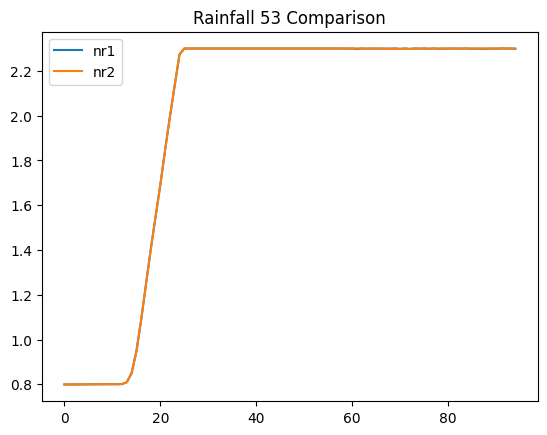

In [15]:
# Plot comparison for one rainfall event
if num_rainfalls > 0:
    plt.plot(comresults['rain3'],label='nr1')
    plt.plot(comresults_2['rain3'],label='nr2')
    plt.legend()
    plt.title('Rainfall 53 Comparison')
    plt.show()


# Export Results

In [16]:
def MPC_interact(rainid): 
    sim = Simulation(f'./SWMM_GR/_temopt/chaohu_rain{rainid}.inp')
    sim.start()

    nodes = Nodes(sim)
    links = Links(sim)
    rgs = RainGages(sim)
    sys = SystemStats(sim)
    
    results = {}
    
    results['CSO'], results['flooding'], results['inflow'] = [0], [0], [0]
    results['total_flooding_time'], results['total_CSO_time'] = [0], [0]
    results['res'] = [0]
    results['state'], results['action'], results['rewards'] = [], [], []

    for i in range(95):
        sim._model.swmm_stride(300)
        results, reward = SWMM_ENV.get_step_results(results,nodes,links,rgs,sys,config,env_params)
        results['rewards'].append(reward)
    
    sim._model.swmm_end() # Terminate simulation
    sim._model.swmm_close() # Close SWMM engine and release resources
    return results

In [17]:
# Process results for all rainfall events
results_MPC = {}
for rainid in range(num_rainfalls):
    # rainid += 50
    print(f'Evaluating rainfall {rainid+1}/{num_rainfalls}')
    results_MPC[f'rainfall{rainid}']=MPC_interact(rainid)

# Save final results
np.save('./results_v5_m_real/MPC_GI',results_MPC)
print(f'Completed processing {num_rainfalls} rainfalls')

Evaluating rainfall 1/54
Evaluating rainfall 2/54
Evaluating rainfall 3/54
Evaluating rainfall 4/54
Completed processing 4 rainfalls
